# Módulo 30 - K-Means
**Atividade:**

Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

In [ ]:
import plotly.express as px
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
penguins = sns.load_dataset('penguins')

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [4]:
penguins.isnull().sum().sum()

np.int64(19)

In [5]:
penguins = penguins.dropna()

In [6]:
penguins.isnull().sum().sum()

np.int64(0)

In [7]:
penguins = penguins.drop(columns=['species', 'island', 'sex'])

In [8]:
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

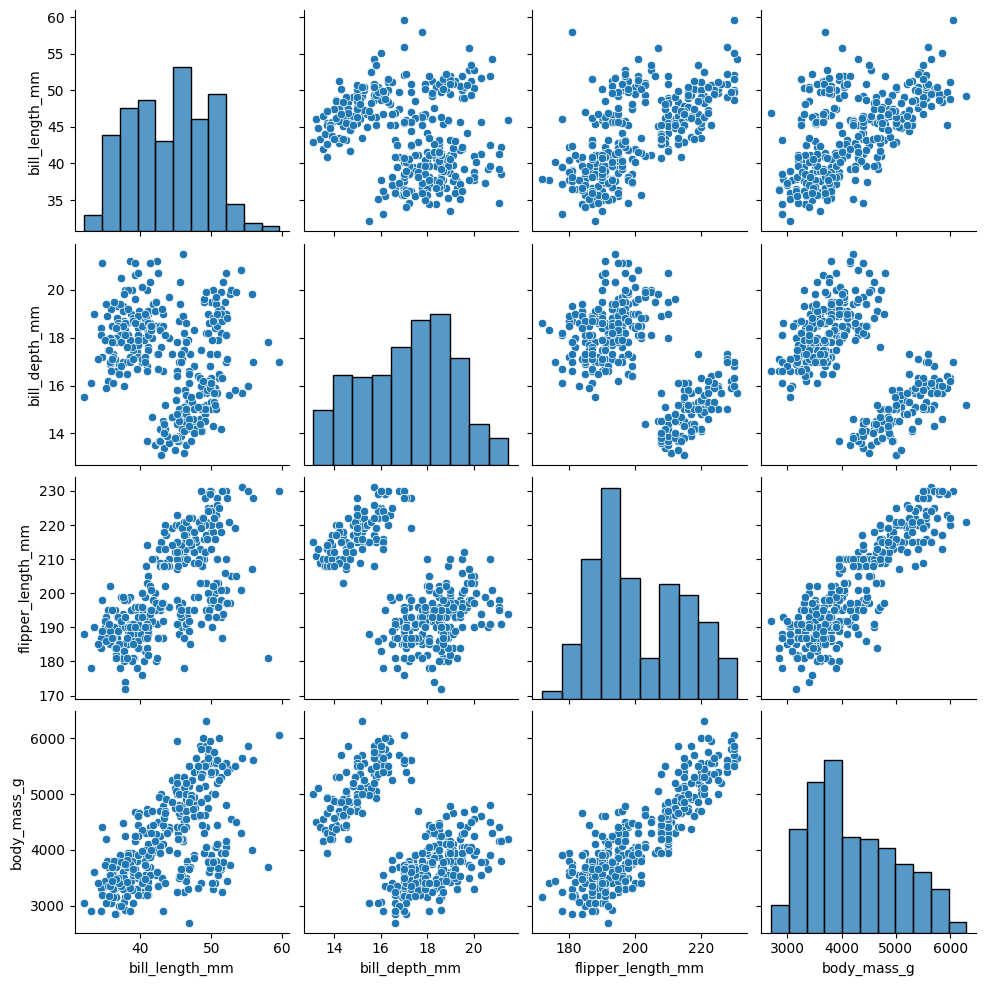

In [9]:
sns.pairplot(penguins)

Sim, a partir do pairplot é possível identificar visualmente a formação de aproximadamente 2 a 3 agrupamentos. Essa separação é mais evidente nas variáveis 'flipper_length_mm', 'body_mass_g' e 'bill_depth_mm', onde os dados formam três conjuntos distintos. Apesar de haver alguma sobreposição entre os grupos em algumas combinações de variáveis, os gráficos sugere, que o algoritmo de agrupamento K-Means, pode encontrar 3 clusters.

# 3 - Realize a padronização dos dados e visualize os dados.

In [11]:
penguins_padronizado = penguins.copy()

In [12]:
colunas_padronizar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
scaler = StandardScaler()
penguins_padronizado[colunas_padronizar] = scaler.fit_transform(penguins[colunas_padronizar])

In [13]:
penguins_padronizado

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
4,-1.335566,1.085877,-0.569284,-0.941606
5,-0.859415,1.747026,-0.783651,-0.692852
...,...,...,...,...
338,0.587352,-1.762145,0.931283,0.892957
340,0.514098,-1.457000,1.002739,0.799674
341,1.173384,-0.744994,1.502928,1.919069
342,0.221082,-1.202712,0.788372,1.234995


# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [14]:
kmeans_penguins = KMeans (n_clusters=3, n_init=10, random_state=42)
kmeans_penguins.fit(penguins_padronizado)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [15]:
centroides = kmeans_penguins.cluster_centers_
centroides

array([[-1.04680889,  0.48662566, -0.88169491, -0.7627539 ],
       [ 0.65475809, -1.10270671,  1.16246305,  1.10121078],
       [ 0.67202511,  0.80526339, -0.28934658, -0.38410387]])

In [20]:
centroides_padronizados = kmeans_penguins.cluster_centers_
centroides_originais = scaler.inverse_transform(centroides_padronizados)
centroides_originais

array([[  38.27674419,   18.12170543,  188.62790698, 3593.79844961],
       [  47.56806723,   14.99663866,  217.23529412, 5092.43697479],
       [  47.66235294,   18.74823529,  196.91764706, 3898.23529412]])

In [21]:
labels = kmeans_penguins.labels_
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

**Conseguimos identificar 3 grupos de pinguins:**

Cluster 0:
- Comprimento médio do bico: 38,28 mm
- Profundidade média do bico: 18,12 mm
- Comprimento médio da nadadeira: 188,63 mm
- Massa corporal média: 3593,80 g

Pinguins de menor porte, com nadadeiras mais curtas, menor massa corporal e bicos menores.

Cluster 1:
- Comprimento médio do bico: 47,57 mm
- Profundidade média do bico: 15,00 mm
- Comprimento médio da nadadeira: 217,24 mm
- Massa corporal média: 5092,44 g

Pinguins de maior porte, com nadadeiras longas, maior massa corporal e bicos compridos, porém menos profundos.

Cluster 2:
- Comprimento médio do bico: 47,66 mm
- Profundidade média do bico: 18,75 mm
- Comprimento médio da nadadeira: 196,92 mm
- Massa corporal média: 3898,24 g

Pinguins de porte intermediário, com massa corporal e comprimento das nadadeiras entre os clusters 0 e 1. Possuem bicos compridos e mais profundos, diferenciando-se principalmente pela profundidade do bico em comparação ao cluster 1.

# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

In [51]:
base_clusters = pd.DataFrame({
    'bill_length_mm': penguins['bill_length_mm'],
    'bill_depth_mm': penguins['bill_depth_mm'],
    'cluster': labels.astype(str)
})

fig = px.scatter(base_clusters, x='bill_length_mm', y='bill_depth_mm', color='cluster',
                color_continuous_scale='viridis', opacity=0.7,
                title='Clusters de bill_length_mm X bill_depth_mm')

fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='bill_length_mm', yaxis_title='bill_depth_mm',
                legend_title='Cluster')
fig.show()

In [52]:
base_clusters = pd.DataFrame({
    'flipper_length_mm': penguins['flipper_length_mm'],
    'bill_length_mm': penguins['bill_length_mm'],
    'cluster': labels.astype(str)
})

fig = px.scatter(base_clusters, x='flipper_length_mm', y='bill_length_mm', color='cluster',
                color_continuous_scale='viridis', opacity=0.7,
                title='Clusters de flipper_length_mm X bill_length_mm')

fig.add_scatter(x=centroides_originais[:, 2], y=centroides_originais[:, 0],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='flipper_length_mm', yaxis_title='bill_length_mm',
                legend_title='Cluster')
fig.show()

In [53]:
base_clusters = pd.DataFrame({
    'body_mass_g': penguins['body_mass_g'],
    'bill_length_mm': penguins['bill_length_mm'],
    'cluster': labels.astype(str)
})

fig = px.scatter(base_clusters, x='body_mass_g', y='bill_length_mm', color='cluster',
                color_continuous_scale='viridis', opacity=0.7,
                title='Clusters de body_mass_g X bill_length_mm')

fig.add_scatter(x=centroides_originais[:, 3], y=centroides_originais[:, 0],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='body_mass_g', yaxis_title='bill_length_mm',
                legend_title='Cluster')
fig.show()

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo:

- Recomendação de produtos: Agrupar usuários com gostos parecidos para sugerir filmes, músicas, livros ou produtos, como fazem plataformas de streaming e e-commerce.

- Cibersegurança: Agrupar padrões de tráfego de rede para identificar comportamentos anormais e detectar possíveis ataques cibernéticos.

- Análise de imagens: Agrupar pixels com características semelhantes para realizar segmentação de imagens, reconhecimento de objetos, compressão de imagens e apoio em diagnósticos médicos por imagens.